In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
idx = pd.IndexSlice

In [3]:
with open(
    Path.cwd().parent / 'config' / 'plotting.default.yaml', 'r'
) as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

In [4]:
bal = pd.read_csv(
    Path.cwd().parent  / 'results' / 'csvs' / 'energy_balance.csv', header=list(range(5)), index_col=[0,1,2]
)
bal.columns = bal.columns.get_level_values(-1).astype(int)
bal.head()

wiggle                                                  0             250   \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.918550e+08  2.563997e+08   
          Offshore Wind (DC)       AC           3.010948e+08  2.839668e+08   
          Offshore Wind (Floating) AC           7.469356e+02  6.748944e+02   
          Onshore Wind             AC           1.024939e+09  1.034054e+09   
          Run of River             AC           1.605181e+08  1.605832e+08   

wiggle                                                  500           750   \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.420462e+08  2.363675e+08   
          Offshore Wind (DC)       AC           2.764314e+08  2.588663e+08   
          Offshore Wind (Floating) AC           2.774986e+02  4.615355e+02   
          Onshore Wind             AC           9.627309e+08  8.774669e+08   
          Run of River             AC           1.610183e+08  1.608973e+08   

wiggle                                                  1000          1250  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.357253e+08  2.363496e+08   
          Offshore Wind (DC)       AC           2.287777e+08  2.250767e+08   
          Offshore Wind (Floating) AC           6.642749e+02  4.735964e+02   
          Onshore Wind             AC           8.418261e+08  7.996371e+08   
          Run of River             AC           1.613242e+08  1.617309e+08   

wiggle                                                  1500          1750  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.314669e+08  2.367359e+08   
          Offshore Wind (DC)       AC           2.297178e+08  2.222453e+08   
          Offshore Wind (Floating) AC           7.106848e+02  6.935899e+02   
          Onshore Wind             AC           7.736297e+08  7.394033e+08   
          Run of River             AC           1.619653e+08  1.619542e+08   

wiggle                                                  2000          2250  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.356687e+08  2.352737e+08   
          Offshore Wind (DC)       AC           2.132387e+08  2.068756e+08   
          Offshore Wind (Floating) AC           6.936563e+02  5.055282e+02   
          Onshore Wind             AC           7.108103e+08  6.888042e+08   
          Run of River             AC           1.618019e+08  1.618685e+08   

wiggle                                          ...          2750  \
component carrier                  bus_carrier  ...                 
Generator Offshore Wind (AC)       AC           ...  2.275130e+08   
          Offshore Wind (DC)       AC           ...  1.621367e+08   
          Offshore Wind (Floating) AC           ...  2.864092e+02   
          Onshore Wind             AC           ...  6.443047e+08   
          Run of River             AC           ...  1.620468e+08   

wiggle                                                  3000          3250  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.303645e+08  2.320342e+08   
          Offshore Wind (DC)       AC           1.312410e+08  8.509936e+07   
          Offshore Wind (Floating) AC           5.997836e+02  3.091148e+02   
          Onshore Wind             AC           6.251590e+08  6.210625e+08   
          Run of River             AC           1.622232e+08  1.623575e+08   

wiggle                                                  3500          3750  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.289933e+08  2.166289e+08   


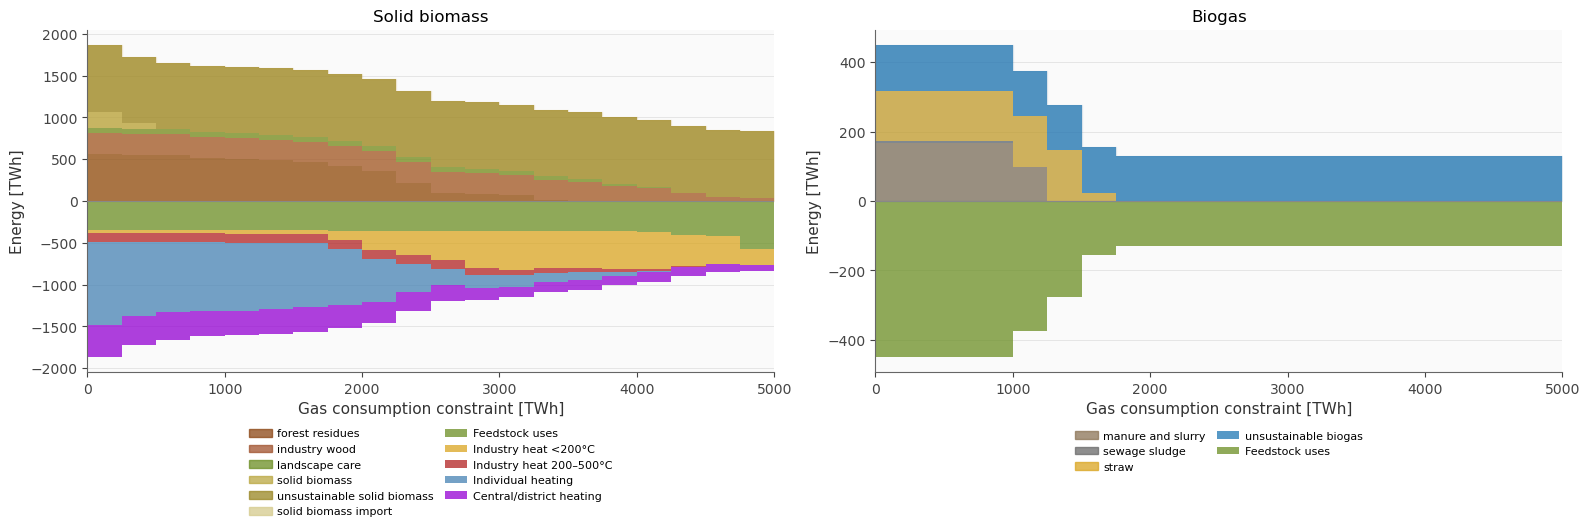

In [9]:
fig, (ax_bm, ax_bg) = plt.subplots(
    nrows=1, ncols=2, figsize=(16, 6), sharex=True
)

axes = [ax_bm, ax_bg]
for ax in axes:
    ax.set_facecolor('#fafafa')
    fig.patch.set_facecolor('white')
    ax.grid(axis='y', color='#dddddd', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#666666')
    ax.spines['bottom'].set_color('#666666')
    ax.tick_params(colors='#444444', labelsize=10)

from matplotlib.patches import Patch

# ========== Legends for each axis ==========
producer_handles_bm, producer_labels_bm = [], []
consumer_handles_bm, consumer_labels_bm = [], []

producer_handles_bg, producer_labels_bg = [], []
consumer_handles_bg, consumer_labels_bg = [], []

# =====================
# Consumer grouping
# =====================
consumer_groups = {
    'biomass to liquid': 'Feedstock uses',
    'biomass-to-methanol': 'Feedstock uses',
    'solid biomass for industry': 'Feedstock uses',
    'solid biomass for industry CC': 'Feedstock uses',
    'biogas to gas': 'Feedstock uses',

    'heat<100 industry solid biomass': 'Industry heat <200°C',
    'heat100-200 industry solid biomass': 'Industry heat <200°C',

    'heat200-500 industry solid biomass': 'Industry heat 200–500°C',

    'urban central solid biomass CHP': 'Central/district heating',
    'urban central solid biomass CHP CC': 'Central/district heating',

    'rural biomass boiler': 'Individual heating',
    'urban decentral biomass boiler': 'Individual heating',
}

consumer_group_colors = {
    'Feedstock uses': '#6B8E23',
    'Industry heat <200°C': '#DAA520',
    'Industry heat 200–500°C': '#B22222',
    'Central/district heating': '#9400D3',
    'Individual heating': '#4682B4',
}
# =====================
# Gather both datasets
# =====================
bg_idx = 'biogas'
df_bg = bal.loc[idx[:, :, bg_idx]].droplevel(0)

bm_idx = 'solid biomass'
df_bm = bal.loc[idx[:, :, bm_idx]].droplevel(0)

# =====================
# Convert MWh -> TWh
# =====================
MWh_to_TWh = 1e-6
df_bg = df_bg * MWh_to_TWh
df_bm = df_bm * MWh_to_TWh

# =====================
# Pre-aggregate consumers by group
# =====================
cols = df_bg.columns  # for both, should be identical

def aggregate_consumers(df, consumer_groups):
    """Sum negative (consumer) values by group. Returns dict of group -> Series."""
    grouped = {}
    for tech in df.index.unique(0):
        data = df.loc[tech]
        neg = data.clip(upper=0)
        if (neg < 0).any():
            group = consumer_groups.get(tech, tech)  # ungrouped keeps original name
            if group not in grouped:
                grouped[group] = pd.Series(0.0, index=cols)
            grouped[group] += neg
    return grouped

consumer_bm = aggregate_consumers(df_bm, consumer_groups)
consumer_bg = aggregate_consumers(df_bg, consumer_groups)

# ========== PLOT solid biomass (left axis) ==========
offset_pos = pd.Series(0.0, index=cols)
offset_neg = pd.Series(0.0, index=cols)

used_for_area_bm = {}

def add_producer_handle(tech, color):
    if tech not in used_for_area_bm:
        producer_handles_bm.append(Patch(facecolor=color, edgecolor=color, alpha=0.75))
        producer_labels_bm.append(tech)
        used_for_area_bm[tech] = True

# --- Plot solid biomass producers (positive only) ---
for tech in df_bm.index.unique(0):
    data = df_bm.loc[tech]
    color = tech_colors.get(tech, None)
    pos = data.clip(lower=0)
    if (pos > 0).any():
        ax_bm.fill_between(
            cols, offset_pos.values + pos.values, offset_pos.values,
            color=color, alpha=0.75, linewidth=0.3, edgecolor='none', step='post'
        )
        add_producer_handle(tech, color)
        offset_pos += pos.values

# Solid biomass aggregate position
agg_bm_pos = offset_pos.copy()

# --- Plot grouped consumers (negative side) ---
used_consumer_groups_bm = set()
for group, vals in consumer_bm.items():
    color = consumer_group_colors.get(group, tech_colors.get(group, '#888888'))
    ax_bm.fill_between(
        cols, offset_neg.values + vals.values, offset_neg.values,
        color=color, alpha=0.75, linewidth=0.3, edgecolor='none', step='post'
    )
    if group not in used_consumer_groups_bm:
        consumer_handles_bm.append(Patch(facecolor=color, alpha=0.75))
        consumer_labels_bm.append(group)
        used_consumer_groups_bm.add(group)
    offset_neg += vals.values

# --- Shaded aggregate band ---
ax_bm.fill_between(
    cols, agg_bm_pos.values, 0,
    color=tech_colors.get('solid_biomass_agg', '#B8860B'),
    alpha=0.12, zorder=1, step='post'
)

ax_bm.axhline(0, color='#888888', linewidth=0.8, zorder=3)
ax_bm.set_xlim(cols[0], cols[-1])
ax_bm.set_title('Solid biomass')
ax_bm.set_xlabel("Gas consumption constraint [TWh]", fontsize=11, color='#333333')
ax_bm.set_ylabel("Energy [TWh]", fontsize=11, color='#333333')

# Legend for solid biomass axis
ax_bm.legend(
    producer_handles_bm + consumer_handles_bm,
    producer_labels_bm  + consumer_labels_bm,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.45),
    ncol=2, fontsize=8,
    frameon=False,
    columnspacing=1.0, handletextpad=0.5
)

# ========== PLOT biogas (right axis) ==========
offset_pos_bg = pd.Series(0.0, index=cols)
offset_neg_bg = pd.Series(0.0, index=cols)
used_for_area_bg = {}

def add_producer_handle_bg(tech, color):
    if tech not in used_for_area_bg:
        producer_handles_bg.append(Patch(facecolor=color, edgecolor=color, alpha=0.75))
        producer_labels_bg.append(tech)
        used_for_area_bg[tech] = True

for tech in df_bg.index.unique(0):
    data = df_bg.loc[tech]
    color = tech_colors.get(tech, None)
    pos = data.clip(lower=0)
    if (pos > 0).any():
        ax_bg.fill_between(
            cols, offset_pos_bg.values + pos.values, offset_pos_bg.values,
            color=color, alpha=0.75, linewidth=0.3, edgecolor='none', step='post'
        )
        add_producer_handle_bg(tech, color)
        offset_pos_bg += pos.values

# Biogas aggregate position
agg_bg_pos = offset_pos_bg.copy()
# No aggregate line

# --- Plot biogas grouped consumers (negative side) ---
used_consumer_groups_bg = set()
for group, vals in consumer_bg.items():
    color = consumer_group_colors.get(group, tech_colors.get(group, '#888888'))
    ax_bg.fill_between(
        cols, offset_neg_bg.values + vals.values, offset_neg_bg.values,
        color=color, alpha=0.75, linewidth=0.3, edgecolor='none', step='post'
    )
    if group not in used_consumer_groups_bg:
        consumer_handles_bg.append(Patch(facecolor=color, alpha=0.75))
        consumer_labels_bg.append(group)
        used_consumer_groups_bg.add(group)
    offset_neg_bg += vals.values

# --- Shaded aggregate band ---
ax_bg.fill_between(
    cols, agg_bg_pos.values, 0,
    color=tech_colors.get('biogas_agg', '#20639B'),
    alpha=0.10, zorder=2, step='post'
)

ax_bg.axhline(0, color='#888888', linewidth=0.8, zorder=3)
ax_bg.set_xlim(cols[0], cols[-1])
ax_bg.set_title('Biogas')
ax_bg.set_xlabel("Gas consumption constraint [TWh]", fontsize=11, color='#333333')
ax_bg.set_ylabel("Energy [TWh]", fontsize=11, color='#333333')

# Legend for biogas axis
ax_bg.legend(
    producer_handles_bg + consumer_handles_bg,
    producer_labels_bg  + consumer_labels_bg,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.32),
    ncol=2, fontsize=8,
    frameon=False,
    columnspacing=1.0, handletextpad=0.5
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.37)
plt.savefig('total_biomass_balance_split.pdf', bbox_inches='tight')
plt.show()

In [56]:
producer_labels

['forest residues',
 'industry wood',
 'landscape care',
 'solid biomass',
 'unsustainable solid biomass',
 'solid biomass import',
 'manure and slurry',
 'sewage sludge',
 'straw',
 'unsustainable biogas']

In [57]:
consumer_labels

['biomass to liquid',
 'biomass-to-methanol',
 'heat100-200 industry solid biomass',
 'heat200-500 industry solid biomass',
 'heat<100 industry solid biomass',
 'rural biomass boiler',
 'solid biomass for industry',
 'solid biomass for industry CC',
 'urban central solid biomass CHP',
 'urban central solid biomass CHP CC',
 'urban decentral biomass boiler',
 'biogas to gas']

Index(['AC', 'co2', 'coal', 'solid biomass', 'gas', 'biogas',
       'municipal solid waste', 'oil primary', 'rural heat',
       'unsustainable bioliquids', 'urban central heat',
       'urban decentral heat', 'EV battery', 'low voltage', 'steel',
       'steel emission', 'hbi', 'Hydrogen Storage', 'co2 stored', 'oil',
       'non-sequestered HVC', 'NH3', 'methanol', 'agriculture machinery oil',
       'Battery Storage', 'co2 sequestered', 'coal for industry',
       'gas for industry', 'heat100-200 industry', 'heat200-500 industry',
       'heat<100 industry', 'heat>500 industry', 'home battery',
       'kerosene for aviation', 'land transport oil', 'naphtha for industry',
       'shipping methanol', 'shipping oil', 'solid biomass for industry',
       'solid biomass import'],
      dtype='object', name='bus_carrier')

In [19]:
bal.loc[idx[:,:,'solid biomass']].index.unique(1)

Index(['forest residues', 'industry wood', 'landscape care', 'solid biomass',
       'unsustainable solid biomass', 'biomass to liquid',
       'biomass-to-methanol', 'heat100-200 industry solid biomass',
       'heat200-500 industry solid biomass', 'heat<100 industry solid biomass',
       'rural biomass boiler', 'solid biomass for industry',
       'solid biomass for industry CC', 'solid biomass import',
       'urban central solid biomass CHP', 'urban central solid biomass CHP CC',
       'urban decentral biomass boiler'],
      dtype='object', name='carrier')

In [20]:
bal.loc[idx[:,:,'biogas']].index.unique(1)

Index(['manure and slurry', 'sewage sludge', 'straw', 'unsustainable biogas',
       'biogas to gas'],
      dtype='object', name='carrier')